# Classification des œuvres de Zola et d'autres naturalistes

## Expérience avec retrait d'une liste de noms propres

## 1. Importation des bibliothèques

In [1]:
# Fichiers et données
import os
import glob
import json
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Représentation textuelle
from sklearn.feature_extraction.text import TfidfVectorizer

# Modèles
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score

# Pipelines et validation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

# Évaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Toutes les bibliothèques sont chargées.")

Toutes les bibliothèques sont chargées.


## 2. Normalisation des apostrophes

Les textes ayant été préalablement nettoyés, certaines apostrophes ont
disparu. Cette étape restaure les contractions les plus fréquentes à partir
d'un dictionnaire de correspondances.

N.b: Les formes `dune` et `lune` sont respectivement interprétées comme `d'une`
et `l'une`. Ce choix repose sur l'hypothèse que les occurrences des noms
communs *dune* et *lune* sont minoritaires dans le corpus étudié.

In [2]:
REMPLACEMENTS_APOSTROPHES = {
    # ========================================================
    # Locutions longues : à traiter avant les formes courtes
    # ========================================================
    "lorsquil": "lorsqu'il",
    "lorsquils": "lorsqu'ils",
    "lorsquon": "lorsqu'on",
    "lorsquune": "lorsqu'une",
    "lorsquun": "lorsqu'un",
    "lorsquelle": "lorsqu'elle",
    "lorsquelles": "lorsqu'elles",

    "puisquil": "puisqu'il",
    "puisquils": "puisqu'ils",
    "puisquon": "puisqu'on",
    "puisquune": "puisqu'une",
    "puisquun": "puisqu'un",
    "puisquelle": "puisqu'elle",
    "puisquelles": "puisqu'elles",

    "quoiquil": "quoiqu'il",
    "quoiquils": "quoiqu'ils",
    "quoiquon": "quoiqu'on",
    "quoiquelle": "quoiqu'elle",

    "jusquil": "jusqu'il",
    "jusquils": "jusqu'ils",
    "jusquon": "jusqu'on",
    "jusquune": "jusqu'une",
    "jusquun": "jusqu'un",
    "jusquelle": "jusqu'elle",
    "jusquelles": "jusqu'elles",
    "jusquà": "jusqu'à",
    "jusquau": "jusqu'au",
    "jusquaux": "jusqu'aux",

    # ========================================================
    # Contractions avec c'
    # ========================================================
    "cest": "c'est",
    "cétait": "c'était",
    "cétaient": "c'étaient",
    "cétant": "c'étant",
    "cen": "c'en",

    # ========================================================
    # Contractions avec s'
    # ========================================================
    "sest": "s'est",
    "sétait": "s'était",
    "sétaient": "s'étaient",
    "sétant": "s'étant",
    "sen": "s'en",
    "sy": "s'y",
    "sil": "s'il",
    "sils": "s'ils",

    # ========================================================
    # Contractions avec n'
    # ========================================================
    "nest": "n'est",
    "nétait": "n'était",
    "nétaient": "n'étaient",
    "navait": "n'avait",
    "navaient": "n'avaient",
    "naurait": "n'aurait",
    "nauraient": "n'auraient",
    "naura": "n'aura",
    "nauront": "n'auront",
    "na": "n'a",
    "nont": "n'ont",
    "nen": "n'en",
    "ny": "n'y",
    "navoir": "n'avoir",
    "nêtre": "n'être",
    "nai": "n'ai",
    "navez": "n'avez",

    # ========================================================
    # Contractions avec j'
    # ========================================================
    "jai": "j'ai",
    "javais": "j'avais",
    "jétais": "j'étais",
    "jaurais": "j'aurais",
    "jaurai": "j'aurai",
    "jaime": "j'aime",
    "jallais": "j'allais",
    "jignore": "j'ignore",
    "jentends": "j'entends",
    "jen": "j'en",
    "jy": "j'y",
    "jirai": "j'irai",
    "tai": "t'ai",

    # ========================================================
    # Contractions avec qu'
    # ========================================================
    "quest": "qu'est",
    "quil": "qu'il",
    "quils": "qu'ils",
    "quon": "qu'on",
    "quun": "qu'un",
    "quune": "qu'une",
    "quà": "qu'à",
    "quen": "qu'en",


    # ========================================================
    # Contractions avec d'
    # ========================================================
    "dune": "d'une", #je prend le parti de mettre d'apostrophe mais il y a un risque de confusion avec "d'une" (de une) et "dune" (la dune) 
    "dun": "d'un",
    "delle": "d'elle",
    "delles": "d'elles",
    "dêtre": "d'être",
    "davoir": "d'avoir",
    "dabord": "d'abord",
    "dailleurs": "d'ailleurs",
    "daprès": "d'après",
    "daccord": "d'accord",
    "davance": "d'avance",
    "doù": "d'où",
    "dautres": "d'autres",
    "damour": "d'amour",
    "dargent": "d'argent",
    "despoir": "d'espoir",
    "den": "d'en",
    "desprit": "d'esprit",
    'deau': "d'eau",

    # ========================================================
    # Contractions avec l'
    # ========================================================
    "labbé": "l'abbé",
    "lair": "l'air",
    "lâme": "l'âme",
    "lami": "l'ami",
    "lamie": "l'amie",
    "lamour": "l'amour",
    "largent": "l'argent",
    "lautre": "l'autre",
    "lun": "l'un",
    "lune": "l'une",
    "lheure": "l'heure",
    "lhomme": "l'homme",
    "lhonneur": "l'honneur",
    "lhistoire": "l'histoire",
    "lhôtel": "l'hôtel",
    "léglise": "l'église",
    "lépoque": "l'époque",
    "lenfant": "l'enfant",
    "lendroit": "l'endroit",
    "lentrée": "l'entrée",
    "lintérieur": "l'intérieur",
    "lidée": "l'idée",
    "lombre": "l'ombre",
    "loeil": "l'œil",
    "lœil": "l'œil",
    "lon": "l'on",
    "lai": "l'ai",
    "lavait": "l'avait",
    "leau": "l'eau",
    "lesprit": "l'esprit",
    "lescalier": "l'escalier",
    "létudiant": "l'étudiant",
    'lavenir': "l'avenir",
    "laffaire": "l'affaire",
    "loreille": "l'oreille",
    "lavocat": "l'avocat",

    # ========================================================
    # Locutions courantes
    # ========================================================
    "aujourdhui": "aujourd'hui",
    "presquun": "presqu'un",
    "presquune": "presqu'une",
    "quelquun": "quelqu'un",
    "quelquune": "quelqu'une",
    "quaprès": "qu'après",

    # ========================================================
    # Verbes pronominaux fréquemment rencontrés
    # ========================================================
    "sécria": "s'écria",
    "sécriait": "s'écriait",
    "sécrièrent": "s'écrièrent",
    "saperçut": "s'aperçut",
    "sapercevait": "s'apercevait",
    "sapprocha": "s'approcha",
    "sapprochait": "s'approchait",
    "sarrêta": "s'arrêta",
    "sarrêtait": "s'arrêtait",
    "sassit": "s'assit",
    "sétendit": "s'étendit",
    "séloigna": "s'éloigna",
    "séloignait": "s'éloignait",
    "sêtre" : "s'être",
    
    # m'
    "men": "m'en",
    "mavez": "m'avez",
    "mavait": "m'avait",
    
    "daller": "d'aller",
    "lappartement": "l'appartement",
    "lhuile": "l'huile",
    "mest": "m'est",
    "dhonneur": "d'honneur",
    "dici": "d'ici",
    "neût": "n'eût",
    "sécrie": "s'écrie",
    "ce quelle": "ce qu'elle",
    "ten": "t'en",
    "dhenriette": "d'Henriette",
    "lart": "l'art",
    "quau": "qu'au",
    "quaux": "qu'aux",
    "dautre": "d'autre",
    "dautres": "d'autres",
    "navais": "n'avais",
    "navions": "n'avions",
    "sagit": "s'agit",
    
    "dœil": "d'œil", 
    "létat": "l'état", 
    "leffet": "l'effet", 
    "jespère": "j'espère", 
    "lhabitude": "l'habitude", 
    "nêtes": "n'êtes",
    "dy": "d'y",
    "linstant ": "l'instant",
    "nimporte": "n'importe",
    
    
    #=============================
    #Artecfact OCR
    #=============================
    "jé":"je",
    "dé":"de", 
    "lé": "le", 
    "mé":"me", 
    "cé":"ce", 
    "qué":"que",
    "dor": "d'or", 
    "my": "m'y", 
    "ten": "t'en",
    "né": "ne",
}

def adapter_casse(forme_originale, remplacement):
    """Conserve approximativement la casse du mot d'origine."""

    if forme_originale.isupper():
        return remplacement.upper()

    if forme_originale[0].isupper():
        return remplacement[0].upper() + remplacement[1:]

    return remplacement


def restaurer_apostrophes(texte):
    """Restaure certaines apostrophes supprimées avec une forte confiance."""

    remplacements_tries = sorted(
        REMPLACEMENTS_APOSTROPHES.items(),
        key=lambda element: len(element[0]),
        reverse=True
    )

    for forme_nettoyee, forme_corrigee in remplacements_tries:
        motif = rf"\b{re.escape(forme_nettoyee)}\b"

        texte = re.sub(
            motif,
            lambda correspondance: adapter_casse(
                correspondance.group(0),
                forme_corrigee
            ),
            texte,
            flags=re.IGNORECASE
        )

    return texte

## 3. Segmentation des fichiers en blocs de 3 lignes

In [3]:
def segmenter_en_paquets(texte, taille_paquet=3):
    lignes = texte.splitlines()
    lignes = [ligne.strip() for ligne in lignes if ligne.strip()]

    paquets = []

    for i in range(0, len(lignes), taille_paquet):
        paquet = " ".join(lignes[i:i + taille_paquet])
        if paquet:
            paquets.append(paquet)
    return paquets


def determiner_label(nom_fichier):
    if nom_fichier.startswith("Émile_Zola"):
        return "Zola"
    return "naturaliste"


def construire_dataframe(liste_fichiers):
    donnees = []

    for chemin_fichier in liste_fichiers:
        nom_fichier = os.path.basename(chemin_fichier)
        label = determiner_label(nom_fichier)

        with open(chemin_fichier, "r", encoding="utf-8") as fichier:
            texte = fichier.read()
        # Restauration appliquée aux deux corpus
        texte = restaurer_apostrophes(texte)
        blocs = segmenter_en_paquets(
            texte)
        for bloc in blocs:
            donnees.append({
                "texte": bloc,
                "label": label,
                "source": nom_fichier
            })
    return pd.DataFrame(donnees)

chemin_dossier = "Data_ZN"

liste_fichiers = sorted(glob.glob(os.path.join(chemin_dossier, "*.txt")))

print(f"Nombre de fichiers trouvés : {len(liste_fichiers)}")

from sklearn.model_selection import StratifiedGroupKFold

df_complet = construire_dataframe(liste_fichiers)

sgkf = StratifiedGroupKFold(
    n_splits=5,       # environ 20 % dans le test
    shuffle=True,
    random_state=42
)

train_indices, test_indices = next(
    sgkf.split(
        X=df_complet["texte"],
        y=df_complet["label"],
        groups=df_complet["source"]
    )
)

df_train = df_complet.iloc[train_indices].reset_index(drop=True)
df_test = df_complet.iloc[test_indices].reset_index(drop=True) 

print("\nTRAIN")
print(df_train["label"].value_counts())
print("Nombre d'œuvres :", df_train["source"].nunique())

print("\nTEST")
print(df_test["label"].value_counts())
print("Nombre d'œuvres :", df_test["source"].nunique())

Nombre de fichiers trouvés : 61

TRAIN
label
Zola           36860
naturaliste    31440
Name: count, dtype: int64
Nombre d'œuvres : 49

TEST
label
Zola           9478
naturaliste    7906
Name: count, dtype: int64
Nombre d'œuvres : 12


## 4. Vérification de la composition des corpus

Cette section vérifie le nombre de segments, les œuvres présentes et leur
répartition entre les classes dans les corpus d'entraînement et de test.

In [4]:
print("Textes dans le train")
print(len(df_train))

sources_par_label = (df_train.groupby("label")["source"].apply(lambda x: x.dropna().unique().tolist()))
print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")
        
print("\n\n\nTextes dans le test")
print(len(df_test))
        
sources_par_label = (df_test.groupby("label")["source"].apply(lambda x: x.dropna().unique().tolist()))
print("-" * 30)
print("Sources par label :")

for label, sources in sources_par_label.items():
    print(f"\n{label} :")
    for source in sources:
        print(f"  - {source}")

Textes dans le train
68300
------------------------------
Sources par label :

Zola :
  - Émile_Zola_Au_Bonheur_des_dames.txt
  - Émile_Zola_Germinal.txt
  - Émile_Zola_L_Argent.txt
  - Émile_Zola_L_Œuvre.txt
  - Émile_Zola_La_Curée.txt
  - Émile_Zola_La_Débâcle.txt
  - Émile_Zola_La_Faute_de_l_abbé_Mouret.txt
  - Émile_Zola_La_Fortune_des_Rougon.txt
  - Émile_Zola_La_Joie_de_vivre.txt
  - Émile_Zola_La_Terre.txt
  - Émile_Zola_Le_Docteur_Pascal.txt
  - Émile_Zola_Le_Rêve.txt
  - Émile_Zola_Le_Ventre_de_Paris.txt
  - Émile_Zola_Nana.txt
  - Émile_Zola_Pot_Bouille.txt
  - Émile_Zola_Son_Excellence_Eugène_Rougon.txt

naturaliste :
  - Alphonse_Daudet_La_Belle_Nivernaise.txt
  - Alphonse_Daudet_Le_Soutien_de_famille.txt
  - Alphonse_Daudet_fromont_jeune_et_risler_ainél.txt
  - Alphonse_Daudet_jack.txt
  - Champfleury_La_Petite_Rose.txt
  - Champfleury_Les_Amis_de_la_nature.txt
  - Champfleury_Les_Confessions_de_Sylvius.txt
  - Edmond_de_Goncourt_La_Faustin.txt
  - Edmond_et_Jules_de_Gonc

In [5]:
# ============================================================
# Construction de la liste des noms propres à retirer
# ============================================================

chemin_json = Path("patronime.json")
with chemin_json.open("r", encoding="utf-8") as fichier:
    personnages_zola = json.load(fichier)

stop_words_noms_propres = [
    # Déjà présents
    "buteau", "florent",  "faujas", "pauline",  "coupeau", "plassans", "nana", "chanteau", "josserand",
    "miette", "lazare", "frédéric", "emma", "arnoux","faustin", "germinie", "duroy", "birotteau",

    # Noms associés aux textes de Zola
    "berthe","martine", "véronique", "kahn",

    # Noms associés aux autres naturalistes
    "joachim", "mathéus", "louveau", "durtal", "émile", "forestier",
    "allart", "césar", "julien", "quesnoy", "francis", "dambreuse", "walter","deslauriers",
    "christiane", "gontran", "rosanette", "andermatt", "lorilleux", "maheude", "trublot",
    "chaval", "delaherche", "fagerolles", "campardon", "delestang", "gavard",
    "poizat", "rastoil", "goujet", "condamin", "aurélie", "hubertine", "jeanlin",
    "bourdoncle", "gilquin", "mahoudeau", "robineau","jory", "hutin", "saturnin", "bouchard", "lerat",
    "chaudoreille", "urbain", "popinot", "corbie", "touquet","gorenflot", "sylvius","charlotte", "stauernaghel", "tillet",
    "julia", "césarine", "max","oriol","rosalie","hamilcar", "colombine", "roy",
      "montsou",

    "rasseneur", "bécu", "zacharie", "hubert", "trouche", "saget", "rognes",
    "hourdequin", "chouteau", "charbonnel", "granoux", "gundermann", "gueulin",
    "marjolin", "boves", "loubet", "ramond","voreux", "gagnière", "marsy", "macqueron",

    # Autres œuvres
    "bird", "roguin", "mâtho",
    "esseintes", "jenkins","spendius","homais", "eudeline", "baudouin", "paule", "popeland",
    "ragon", "niflart", "perrin", "izoard", "brétigny",
    "rodolphe", "marcel", "anselme", "rouquette", "lapoulle", "dubuche", "gourd", "sarriette",
    "rochas", "mazaud", "bonneville", "vabre", "favier", "bazeilles",
    "paloque", "lengaigne", "béjuin","dide", "meuse", "henriette", "claparon", "jansoulet", "bigle",
    "tournelles", "lestang", "guay", "lefèvre", "carthage",  "sénécal",
    "hussonnet", "germain", "félix", "juzeur", "delangre", "lecœur", "bongrand", "nénesse", "bonnemort",
    "bourrette", "vallagnosc", "jantrou", "deloche", "roudier", "neuville", "villebelle",
    "dina", "christian", "marelle","albine", "fauchery", "bordenave", "muffat",
    "lévise", "dingo", "andré", "cyprien", "simonne"    
]
    
stop_words_noms_propres_set = set()

for personnage in personnages_zola:
    for champ in ("prenom", "nom"):
        valeur = personnage.get(champ, "")

        mots = re.findall(r"\b[\wÀ-ÿ'-]+\b",valeur.lower())

        stop_words_noms_propres_set.update(mots)

stop_words_noms_propres_set.update(mot.lower()for mot in stop_words_noms_propres)

stop_words = sorted(stop_words_noms_propres_set)

print(
    "Nombre total de noms propres retirés :",
    len(stop_words)
)

# Séparation des textes et des labels
X_train = df_train["texte"].fillna("")
y_train = df_train["label"]

X_test = df_test["texte"].fillna("")
y_test = df_test["label"]


# ====================================================================
# # Construction de la représentation TF-IDF commune aux trois modèles
# ====================================================================


vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9,
    stop_words=stop_words
)

# Le vocabulaire et les poids IDF sont appris uniquement sur le train
vectorizer.fit(X_train)

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Dimensions du train :", X_train_tfidf.shape)
print("Dimensions du test  :", X_test_tfidf.shape)

Nombre total de noms propres retirés : 502
Dimensions du train : (68300, 10000)
Dimensions du test  : (17384, 10000)


## 7. Validation croisée groupée et sélection du modèle

Les trois modèles sont évalués sur les mêmes plis de
`StratifiedGroupKFold`. Les segments d'une même œuvre restent dans un seul
groupe afin d'éviter qu'une œuvre apparaisse simultanément dans
l'entraînement et la validation.

Le critère principal de sélection est le F1 macro moyen.

In [6]:
X = df_train["texte"].fillna("").to_numpy()
Y = df_train["label"].to_numpy()
groups = df_train["source"].to_numpy()

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Les plis sont calculés une seule fois pour garantir la même
# séparation pour tous les modèles.
plis = list(cv.split(X, Y, groups=groups))


modeles = {
    "Naive Bayes": Pipeline([
        ("tfidf", vectorizer),
        ("clf", MultinomialNB(alpha=1.0))
    ]),

    "Régression logistique": Pipeline([
        ("tfidf", vectorizer),
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42
        ))
    ]),

    "LDA": Pipeline([
        ("tfidf", vectorizer),
        ("svd", TruncatedSVD(
            n_components=100,
            random_state=42
        )),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(
            solver="svd"
        ))
    ])
}

resultats = []

for nom, modele in modeles.items():
    scores = cross_validate(
        modele,
        X,
        Y,
        cv=plis,
        scoring={
            "f1_macro": "f1_macro",
            "accuracy": "accuracy"
        },
        return_train_score=True,
        n_jobs=1  # mettre -1 uniquement si la mémoire disponible le permet
    )

    resultats.append({
        "modèle": nom,
        "F1 macro moyen": scores["test_f1_macro"].mean(),
        "écart-type F1": scores["test_f1_macro"].std(),
        "accuracy moyenne": scores["test_accuracy"].mean(),
        "F1 entraînement": scores["train_f1_macro"].mean()
    })

comparaison_cv = (
    pd.DataFrame(resultats)
    .sort_values("F1 macro moyen", ascending=False)
    .reset_index(drop=True)
)

for numero, (indices_train, indices_validation) in enumerate(plis, start=1):
    sources_train = set(groups[indices_train])
    sources_validation = set(groups[indices_validation])

    intersection = sources_train & sources_validation

    print(
        f"Pli {numero} : "
        f"{len(sources_train)} œuvres train, "
        f"{len(sources_validation)} œuvres validation, "
        f"intersection = {len(intersection)}"
    )

    assert len(intersection) == 0
    
display(comparaison_cv)

Pli 1 : 39 œuvres train, 10 œuvres validation, intersection = 0
Pli 2 : 40 œuvres train, 9 œuvres validation, intersection = 0
Pli 3 : 38 œuvres train, 11 œuvres validation, intersection = 0
Pli 4 : 39 œuvres train, 10 œuvres validation, intersection = 0
Pli 5 : 40 œuvres train, 9 œuvres validation, intersection = 0


,modèle,F1 macro moyen,écart-type F1,accuracy moyenne,F1 entraînement
0,Régression logistique,0.817085,0.014467,0.818629,0.912413
1,Naive Bayes,0.752425,0.031093,0.756384,0.842222
2,LDA,0.722888,0.028269,0.728146,0.763922


## 8. Entraînement final et évaluation sur le corpus de test

### 8.1 Naive Bayes multinomial

              precision    recall  f1-score   support

        Zola       0.74      0.81      0.77      9478
 naturaliste       0.74      0.66      0.70      7906

    accuracy                           0.74     17384
   macro avg       0.74      0.73      0.74     17384
weighted avg       0.74      0.74      0.74     17384

[[7657 1821]
 [2686 5220]]


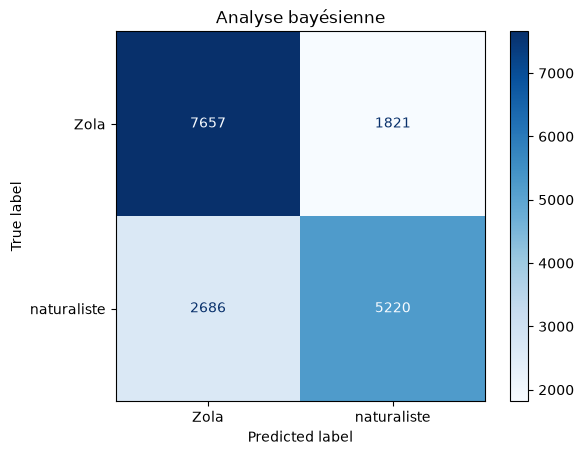

In [7]:
modele_bayes = MultinomialNB(alpha=1)

modele_bayes.fit(X_train_tfidf, y_train)


predictions = modele_bayes.predict(X_test_tfidf)

print(classification_report(y_test, predictions))

cm_bayesien = confusion_matrix(y_test, predictions)
print(cm_bayesien)

ConfusionMatrixDisplay(
    confusion_matrix=cm_bayesien,
    display_labels=modele_bayes.classes_
).plot(cmap="Blues")

plt.title("Analyse bayésienne")
plt.show()

### 8.2 Régression logistique

=== Régression logistique ===
              precision    recall  f1-score   support

        Zola      0.839     0.864     0.851      9478
 naturaliste      0.831     0.801     0.816      7906

    accuracy                          0.835     17384
   macro avg      0.835     0.833     0.833     17384
weighted avg      0.835     0.835     0.835     17384

Matrice de confusion :
[[8189 1289]
 [1573 6333]]


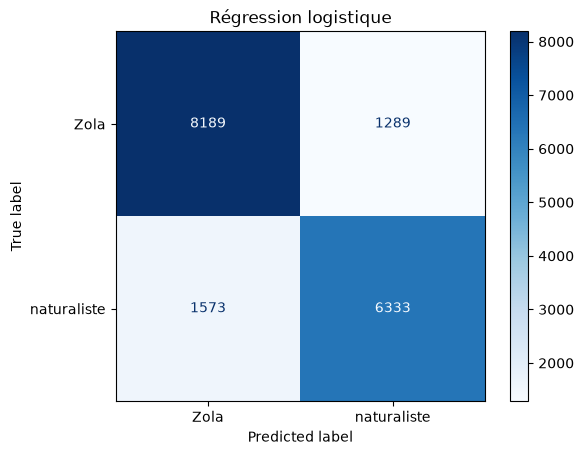

In [8]:
# Entraînement direct, sans Pipeline
modele_logistique = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

modele_logistique.fit(X_train_tfidf, y_train)

predictions_logistiques = modele_logistique.predict(X_test_tfidf)

print("=== Régression logistique ===")
print(classification_report(y_test, predictions_logistiques, digits=3))

cm_logistique = confusion_matrix(y_test, predictions_logistiques)
print("Matrice de confusion :")
print(cm_logistique)

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistique,
    display_labels=modele_logistique.classes_
).plot(cmap="Blues")

plt.title("Régression logistique")
plt.show()

In [9]:
print("Balanced accuracy :", balanced_accuracy_score(y_test,predictions_logistiques))

Balanced accuracy : 0.8325190155032756


### 8.3 Analyse discriminante linéaire après réduction SVD

L'analyse discriminante linéaire ne travaille pas directement sur une matrice TF-IDF creuse comportant plusieurs milliers de colonnes. On réduit donc d'abord la dimension avec `TruncatedSVD`, puis on standardise les composantes avant d'entraîner la LDA.

=== Analyse discriminante linéaire ===
Nombre de composantes SVD : 100
Variance expliquée cumulée par la SVD : 0.148
              precision    recall  f1-score   support

        Zola      0.740     0.815     0.776      9478
 naturaliste      0.747     0.657     0.699      7906

    accuracy                          0.743     17384
   macro avg      0.744     0.736     0.737     17384
weighted avg      0.743     0.743     0.741     17384

Matrice de confusion :
[[7723 1755]
 [2715 5191]]


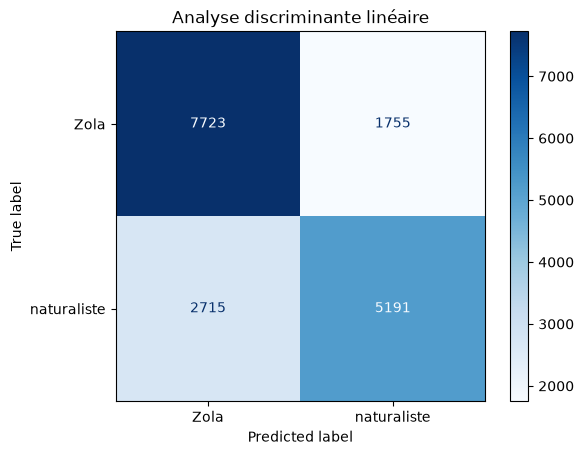

In [10]:
# Nombre de composantes compatible avec la taille réelle des données
n_composantes = min(
    100,
    X_train_tfidf.shape[0] - 1,
    X_train_tfidf.shape[1] - 1)

# Réduction de dimension
svd = TruncatedSVD(
    n_components=n_composantes,
    random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

# Standardisation
scaler_lda = StandardScaler()
X_train_lda = scaler_lda.fit_transform(X_train_svd)
X_test_lda = scaler_lda.transform(X_test_svd)

# Analyse discriminante linéaire
modele_lda = LinearDiscriminantAnalysis(solver="svd")
modele_lda.fit(X_train_lda, y_train)

predictions_lda = modele_lda.predict(X_test_lda)

print("=== Analyse discriminante linéaire ===")
print(f"Nombre de composantes SVD : {n_composantes}")
print(
    "Variance expliquée cumulée par la SVD : "
    f"{svd.explained_variance_ratio_.sum():.3f}"
)
print(classification_report(y_test, predictions_lda, digits=3))

cm_lda = confusion_matrix(y_test, predictions_lda)
print("Matrice de confusion :")
print(cm_lda)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda,
    display_labels=modele_lda.classes_
).plot(cmap="Blues")

plt.title("Analyse discriminante linéaire")
plt.show()


## 9. Comparaison des performances sur le corpus de test

Les résultats du corpus de test sont présentés après la sélection du modèle
par validation croisée. Ils constituent une évaluation complémentaire.

In [11]:
comparaison_modeles = pd.DataFrame({
    "modèle": [
        "Analyse bayésienne",
        "Régression logistique",
        "Analyse discriminante linéaire"
    ],

    "accuracy": [
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, predictions_logistiques),
        accuracy_score(y_test, predictions_lda)
    ],

    "f1_macro": [
        f1_score(y_test, predictions, average="macro"),
        f1_score(y_test, predictions_logistiques, average="macro"),
        f1_score(y_test, predictions_lda, average="macro")
    ]
})

print("\nComparaison des modèles sur le jeu de test :")

comparaison_modeles.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)


Comparaison des modèles sur le jeu de test :


,modèle,accuracy,f1_macro
0,Régression logistique,0.835366,0.833468
1,Analyse discriminante linéaire,0.742867,0.737294
2,Analyse bayésienne,0.740739,0.735541


## 10. Évaluation finale au niveau des œuvres

Les probabilités des segments appartenant à une même œuvre sont moyennées
afin d'obtenir une prédiction unique par œuvre.

In [12]:
probabilites = modele_logistique.predict_proba(
    X_test_tfidf
)

classe_zola = list(
    modele_logistique.classes_
).index("Zola")

evaluation_oeuvres = df_test[
    ["source", "label"]
].copy()

evaluation_oeuvres["probabilite_zola"] = (
    probabilites[:, classe_zola]
)

resultats_oeuvres = (
    evaluation_oeuvres
    .groupby("source")
    .agg(
        label_reel=("label", "first"),
        probabilite_zola=(
            "probabilite_zola",
            "mean"
        )
    )
    .reset_index()
)

resultats_oeuvres["prediction"] = np.where(
    resultats_oeuvres["probabilite_zola"] >= 0.5,
    "Zola",
    "naturaliste"
)

print(
    classification_report(
        resultats_oeuvres["label_reel"],
        resultats_oeuvres["prediction"],
        digits=3
    )
)

resultats_oeuvres

              precision    recall  f1-score   support

        Zola      1.000     1.000     1.000         4
 naturaliste      1.000     1.000     1.000         8

    accuracy                          1.000        12
   macro avg      1.000     1.000     1.000        12
weighted avg      1.000     1.000     1.000        12



,source,label_reel,probabilite_zola,prediction
0,Alphonse_Daudet_Le_Nabab.txt,naturaliste,0.201182,naturaliste
1,Alphonse_Daudet_Les_Rois_en_exil.txt,naturaliste,0.229262,naturaliste
2,Edmond_de_Goncourt_Les_Frères_Zemganno.txt,naturaliste,0.215166,naturaliste
3,Guy_de_Maupassant_Une_vie.txt,naturaliste,0.356533,naturaliste
4,J_H_Rosny_Nymphée.txt,naturaliste,0.310520,naturaliste
5,Joris_Karl_Huysmans_En_ménage.txt,naturaliste,0.322186,naturaliste
6,Louis_Émile_Edmond_Duranty_Le_Malheur_d_Henrie...,naturaliste,0.257509,naturaliste
7,Octave_Mirbeau_calvaire.txt,naturaliste,0.324800,naturaliste
8,Émile_Zola_L_Assommoir.txt,Zola,0.790337,Zola
9,Émile_Zola_La_Bête_humaine.txt,Zola,0.767921,Zola


## 11. Interprétation des modèles à partir du corpus d'entraînement

Cette section examine les paramètres appris par les modèles, sans tenir
compte de la fréquence des termes dans le corpus de test.

### 11.1 Termes caractéristiques selon Naive Bayes

In [13]:
classifieur = modele_bayes

mots = vectorizer.get_feature_names_out()
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Différence des log-probabilités entre les deux classes
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats_mots = pd.DataFrame({
    "mot": mots,
    f"score_{classes[0]}": score_discriminant
})

# Mots les plus caractéristiques de la première classe
mots_classe_0 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=False
).head(30)

# Mots les plus caractéristiques de la deuxième classe
mots_classe_1 = resultats_mots.sort_values(
    f"score_{classes[0]}",
    ascending=True
).head(30)

print(f"\nMots les plus caractéristiques de {classes[0]} :")
for _, ligne in mots_classe_0.iterrows():
    print(f"{ligne['mot']:<25} {ligne[f'score_{classes[0]}']:.3f}")

print(f"\nMots les plus caractéristiques de {classes[1]} :")
for _, ligne in mots_classe_1.iterrows():
    print(f"{ligne['mot']:<25} {-ligne[f'score_{classes[0]}']:.3f}")

Ordre des classes : ['Zola' 'naturaliste']

Mots les plus caractéristiques de Zola :
prussiens                 3.480
teuse                     3.455
vandeuvres                3.374
empereur                  3.318
faloise                   3.284
steiner                   3.151
fontan                    3.122
labordette                3.112
les prussiens             3.085
coron                     3.069
sedan                     3.010
insurgés                  2.909
paradou                   2.892
fanny                     2.781
archangias                2.742
frère archangias          2.742
normande                  2.676
belle normande            2.614
cadine                    2.614
mineurs                   2.601
jésus christ              2.538
larsonneau                2.535
daigremont                2.534
obus                      2.532
porion                    2.503
charcuterie               2.485
les insurgés              2.459
entêtait                  2.430
murmura il         

### 11.2 Coefficients de la régression logistique

In [14]:
# Termes les plus discriminants de la régression logistique
termes_logistiques = vectorizer.get_feature_names_out()
classes_logistiques = modele_logistique.classes_

print("Ordre des classes :", classes_logistiques)

# En classification binaire :
# - coefficient positif  -> classe classes_[1]
# - coefficient négatif  -> classe classes_[0]
coefficients = modele_logistique.coef_[0]

importance_logistique = pd.DataFrame({
    "terme": termes_logistiques,
    "coefficient": coefficients
})

n = 30

termes_classe_0 = (
    importance_logistique
    .sort_values("coefficient", ascending=True)
    .head(n))

termes_classe_1 = (
    importance_logistique
    .sort_values("coefficient", ascending=False)
    .head(n))

print(f"\nTermes les plus associés à {classes_logistiques[0]} :")
for _, ligne in termes_classe_0.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

print(f"\nTermes les plus associés à {classes_logistiques[1]} :")
for _, ligne in termes_classe_1.iterrows():
    print(f"{ligne['terme']:<30} {ligne['coefficient']:.4f}")

Ordre des classes : ['Zola' 'naturaliste']

Termes les plus associés à Zola :
lorsque                        -7.0996
empereur                       -6.6422
qu elle                        -5.1317
ça                             -4.8858
oncle                          -4.6234
lorsqu                         -4.5312
simplement                     -4.4892
hein                           -4.3630
tante                          -4.0850
justement                      -4.0708
dut                            -4.0582
ce fut                         -4.0423
ce pas                         -3.9919
non non                        -3.8226
finit                          -3.7972
tout suite                     -3.6830
achevait                       -3.5645
tout un                        -3.4082
universelle                    -3.3725
prussiens                      -3.3493
empire                         -3.3406
au fond                        -3.3366
murmura                        -3.3107
face                     

## 12. Analyse post-hoc du corpus de test

Cette section examine les termes effectivement présents dans le corpus de
test. Elle est uniquement interprétative et n'est pas utilisée pour
modifier le prétraitement, sélectionner le modèle ou régler ses
hyperparamètres.

### 12.1 Présence et poids TF-IDF des termes dans le test

In [15]:
# Utilisation du TF-IDF commun
classifieur = modele_bayes

# Vocabulaire appris sur le train
termes = vectorizer.get_feature_names_out()

# Ordre réel des classes
classes = classifieur.classes_

print("Ordre des classes :", classes)

# Nombre d'extraits du test contenant chaque terme
presence_test = np.asarray((X_test_tfidf > 0).sum(axis=0)).ravel()

# Somme des poids TF-IDF de chaque terme dans le test
poids_tfidf_test = np.asarray(X_test_tfidf.sum(axis=0)).ravel()

# Score discriminant appris par Naive Bayes
# score positif : classe 0
# score négatif : classe 1
score_discriminant = (
    classifieur.feature_log_prob_[0]
    - classifieur.feature_log_prob_[1]
)

resultats = pd.DataFrame({
    "terme": termes,
    "score_discriminant": score_discriminant,
    "nb_extraits_test": presence_test,
    "poids_tfidf_test": poids_tfidf_test
})

# On conserve uniquement les termes présents dans le test
resultats_test = resultats[
    resultats["nb_extraits_test"] > 0
].copy()

print(f"\nNombre de termes du vocabulaire présents dans le test : "
      f"{len(resultats_test)}")

Ordre des classes : ['Zola' 'naturaliste']

Nombre de termes du vocabulaire présents dans le test : 9879


### 12.2 Termes discriminants de Naive Bayes présents dans le test

In [16]:
n = 30

termes_classe_0 = (
    resultats_test
    .sort_values("score_discriminant", ascending=False)
    .head(n)
)

termes_classe_1 = (
    resultats_test
    .sort_values("score_discriminant", ascending=True)
    .head(n)
)

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[0]} :")

for _, ligne in termes_classe_0.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}"
    )

print(f"\nTermes présents dans le test les plus caractéristiques de {classes[1]} :")

for _, ligne in termes_classe_1.iterrows():
    print(
        f"{ligne['terme']:<25} "
        f"score={-ligne['score_discriminant']:.3f}  "
        f"extraits={int(ligne['nb_extraits_test'])}")


Termes présents dans le test les plus caractéristiques de Zola :
prussiens                 score=3.480  extraits=20
empereur                  score=3.318  extraits=26
les prussiens             score=3.085  extraits=11
sedan                     score=3.010  extraits=1
normande                  score=2.676  extraits=10
cadine                    score=2.614  extraits=1
obus                      score=2.532  extraits=4
charcuterie               score=2.485  extraits=5
entêtait                  score=2.430  extraits=18
murmura il                score=2.410  extraits=78
fit remarquer             score=2.401  extraits=14
le colonel                score=2.382  extraits=5
bonheur des               score=2.378  extraits=4
le pis                    score=2.376  extraits=14
caporal                   score=2.362  extraits=1
clientes                  score=2.347  extraits=3
impératrice               score=2.319  extraits=9
beauce                    score=2.319  extraits=3
ses jupes                 

### 12.3 Contribution lexicale globale dans le corpus de test

L'indicateur ci-dessous combine le caractère discriminant appris par
Naive Bayes avec le poids TF-IDF total du terme dans le corpus de test.

Il s'agit d'un indicateur descriptif global. Il ne représente pas une
explication locale exacte de chaque prédiction.

In [17]:
resultats_test["contribution_test"] = (
    resultats_test["score_discriminant"]
    * resultats_test["poids_tfidf_test"]
)

contributions_zola = (
    resultats_test
    .sort_values("contribution_test", ascending=False)
    .head(30)
)

contributions_naturalistes = (
    resultats_test
    .sort_values("contribution_test", ascending=True)
    .head(30)
)


print(contributions_zola[["terme", "contribution_test"]])
print(contributions_naturalistes[["terme", "contribution_test"]])

           terme  contribution_test
2564        elle         404.641793
7052     qu elle         164.794101
9852       était         144.227895
603        avait         128.083648
9713          ça         124.170954
2576  elle avait          79.849404
4742         les          76.026353
2619     elle ne          70.783544
5005     lorsque          69.323092
9           abbé          68.937443
4998      lorsqu          68.636778
4102         ils          67.716065
3193         eut          67.459127
2672  elle était          66.237842
7046          qu          64.237498
2648     elle se          61.660711
9379      venait          60.932380
9181         une          60.785853
9061     un coup          56.354203
5635     murmura          56.308766
1806        cria          53.559652
3099     et elle          51.718988
7475     restait          49.527886
8425        sous          49.285091
5099          là          48.876866
3198      eut un          48.691169
3943    il avait          48

In [18]:
evaluation = df_test[["source", "label"]].copy()
evaluation["prediction"] = predictions_logistiques

performance_par_oeuvre = (
    evaluation
    .groupby("source")
    .apply(
        lambda groupe: pd.Series({
            "label_reel": groupe["label"].iloc[0],
            "n_segments": len(groupe),
            "accuracy_segments": (
                groupe["prediction"]
                == groupe["label"]
            ).mean(),
            "prediction_majoritaire": (
                groupe["prediction"]
                .value_counts()
                .idxmax()
            )
        }),
        include_groups=False
    )
    .reset_index()
)

print(performance_par_oeuvre)

print(
    "Accuracy moyenne par œuvre :",
    performance_par_oeuvre[
        "accuracy_segments"
    ].mean()
)

                                               source   label_reel  \
0                        Alphonse_Daudet_Le_Nabab.txt  naturaliste   
1                Alphonse_Daudet_Les_Rois_en_exil.txt  naturaliste   
2          Edmond_de_Goncourt_Les_Frères_Zemganno.txt  naturaliste   
3                       Guy_de_Maupassant_Une_vie.txt  naturaliste   
4                               J_H_Rosny_Nymphée.txt  naturaliste   
5                   Joris_Karl_Huysmans_En_ménage.txt  naturaliste   
6   Louis_Émile_Edmond_Duranty_Le_Malheur_d_Henrie...  naturaliste   
7                         Octave_Mirbeau_calvaire.txt  naturaliste   
8                          Émile_Zola_L_Assommoir.txt         Zola   
9                      Émile_Zola_La_Bête_humaine.txt         Zola   
10             Émile_Zola_La_Conquête_de_Plassans.txt         Zola   
11                    Émile_Zola_Une_page_d_amour.txt         Zola   

    n_segments  accuracy_segments prediction_majoritaire  
0          634           0.903